# Final analysis

Eniac wants to know if it's beneficial to discount products.

- The Marketing Team Lead is convinced that offering discounts is beneficial in the long run. She believes discounts improve customer acquisition, satisfaction and retention, and allow the company to grow.
- The main investors in the Board are worried about offering aggressive discounts. They have pointed out how the company’s recent quarterly results showed an increase in orders placed, but a decrease in the total revenue. They prefer that the company positions itself in the quality segment, rather than competing to offer the lowest prices in the market.

### Business questions

- How should products be classified into different categories to simplify reports and analysis?
- What is the distribution of product prices across different categories?
- How many products are being discounted?
- How big are the offered discounts as a percentage of the product prices?
- **How do seasonality and special dates (Christmas, Black Friday) affect sales?**
- **How could data collection be improved?**

*This analysis deals with the last 2 questions*

### Set up

In [1]:
# import sys
# !{sys.executable} -m pip install seaborn

In [68]:
import pandas as pd
import seaborn as sns

#read in cleaned, quality controlled data
orderlines_qu = pd.read_csv('data_cleaned/orderlines_qu.csv', parse_dates=['date'])
orders_qu = pd.read_csv('data_cleaned/orders_qu.csv', parse_dates=['created_date'])
products_cl = pd.read_csv('data_cleaned/products_clean.csv')
product_category = pd.read_csv('data_cleaned/products_category_up.csv')


In [69]:
orderlines = orderlines_qu.copy()
orders = orders_qu.copy()
products = product_category.copy()

In [70]:
orderlines.info()

<class 'pandas.DataFrame'>
RangeIndex: 45206 entries, 0 to 45205
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   id_order                45206 non-null  int64         
 1   product_id              45206 non-null  int64         
 2   product_quantity        45206 non-null  int64         
 3   sku                     45206 non-null  str           
 4   date                    45206 non-null  datetime64[us]
 5   unit_price              45206 non-null  float64       
 6   unit_price_total        45206 non-null  float64       
 7   product_price           45206 non-null  float64       
 8   products_price_diff     45206 non-null  float64       
 9   pc_products_price_diff  45206 non-null  float64       
 10  index                   45206 non-null  int64         
dtypes: datetime64[us](1), float64(5), int64(4), str(1)
memory usage: 3.8 MB


In [71]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 36232 entries, 0 to 36231
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          36232 non-null  int64         
 1   total_paid        36232 non-null  float64       
 2   state             36232 non-null  str           
 3   created_date      36232 non-null  datetime64[us]
 4   unit_price_total  36232 non-null  float64       
 5   price_diff        36232 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(1), str(1)
memory usage: 1.7 MB


In [72]:
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 10202 entries, 0 to 10201
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   sku       10202 non-null  str    
 1   name      10202 non-null  str    
 2   desc      10202 non-null  str    
 3   price     10202 non-null  float64
 4   in_stock  10202 non-null  int64  
 5   type      10155 non-null  str    
 6   text      10202 non-null  str    
 7   category  10202 non-null  str    
dtypes: float64(1), int64(1), str(6)
memory usage: 637.8 KB


In [73]:
products['category'].value_counts(normalize=True)

category
Accessories: cases         0.338659
Cables and Connectivity    0.221623
Storage                    0.080768
Apple Laptop               0.070084
Apple Display              0.066752
Other Tech                 0.060576
Server                     0.054205
Apple Smartphone           0.031660
Displays                   0.022545
Apple Tablet               0.021172
Components                 0.020878
Apple Mediaplayer          0.005783
Apple Watch                0.004313
Other tablet               0.000784
Samsung products           0.000196
Name: proportion, dtype: float64

Merge products with orderlines to get product categories

In [74]:
orderlines.shape
orderlines = orderlines.merge(products, on = 'sku', how = 'left')
orderlines.shape

(45206, 18)

Because we have 15 months of data and we want to compare revenue, orders, discounts relative to a yearly average, let's subset the data so we only have 1 fiscal year (April to March)

In [75]:
orders = orders[orders['created_date'] >= '2017-04-01']
orders['created_date'].describe()

count                         30905
mean     2017-10-29 04:48:46.565701
min             2017-04-01 09:04:39
25%             2017-08-25 18:33:45
50%             2017-11-24 11:44:08
75%             2018-01-02 09:31:22
max             2018-03-14 11:57:46
Name: created_date, dtype: object

calculate discount as product_price - unit_price, then calculate a weighted discount per order as the sum of (discount * qty) divided by the sum of (original price * qty)

In [76]:
orderlines['discount'] = orderlines['product_price'] - orderlines['unit_price']
orderlines['total_discount'] = orderlines['discount']*orderlines['product_quantity']
orderlines['total_price'] = orderlines['product_price']*orderlines['product_quantity']

#weighted discount per order
order_discount = orderlines.groupby('id_order').agg(order_discount=('total_discount', 'sum'), order_price=('total_price', 'sum'))

order_discount['order_weighted_discount'] = order_discount['order_discount']/order_discount['order_price']
order_discount = order_discount.reset_index()
order_discount.sample(10)

,id_order,order_discount,order_price,order_weighted_discount
9994,374619,40.00,329.00,0.121581
25903,465728,64.91,409.89,0.158360
20956,437980,85.00,300.99,0.282401
9607,371818,40.00,329.00,0.121581
9303,369899,30.98,227.95,0.135907
32949,507037,26.00,131.99,0.196985
11337,382151,43.90,809.89,0.054205
2450,312856,37.06,279.99,0.132362
21454,440054,40.68,247.97,0.164052
23737,452046,0.00,240.99,0.000000


merge with orders

In [77]:
orders = orders.merge(order_discount, left_on  ='order_id', right_on = 'id_order', how = 'left')
orders.head()

,order_id,total_paid,state,created_date,unit_price_total,price_diff,id_order,order_discount,order_price,order_weighted_discount
0,241423,136.15,Completed,2017-11-06 13:10:02,129.16,6.99,241423,10.83,139.99,0.077363
1,245275,149.00,Completed,2017-06-28 11:35:37,149.00,0.00,245275,30.00,179.00,0.167598
2,247524,167.98,Completed,2018-01-09 14:21:34,162.99,4.99,247524,0.99,163.98,0.006037
3,247643,153.54,Completed,2017-05-26 11:50:35,153.54,0.00,247643,26.45,179.99,0.146953
4,250275,54.99,Completed,2017-11-19 22:34:54,51.00,3.99,250275,19.00,70.00,0.271429


Create colourblind friendly colour palette

In [78]:
plot_colours = ['#0072B2', '#E69F00', '#009E73']

## Analysis

### Seasonality and sales

In [79]:
orders.head()

,order_id,total_paid,state,created_date,unit_price_total,price_diff,id_order,order_discount,order_price,order_weighted_discount
0,241423,136.15,Completed,2017-11-06 13:10:02,129.16,6.99,241423,10.83,139.99,0.077363
1,245275,149.00,Completed,2017-06-28 11:35:37,149.00,0.00,245275,30.00,179.00,0.167598
2,247524,167.98,Completed,2018-01-09 14:21:34,162.99,4.99,247524,0.99,163.98,0.006037
3,247643,153.54,Completed,2017-05-26 11:50:35,153.54,0.00,247643,26.45,179.99,0.146953
4,250275,54.99,Completed,2017-11-19 22:34:54,51.00,3.99,250275,19.00,70.00,0.271429


Calculate indices for Revenue, Number of orders, and weighted_discount against the monthly average

In [80]:
orders['month'] = orders['created_date'].dt.to_period("M")
monthly = orders.groupby('month').agg(revenue=('total_paid', 'sum'), orders=('order_id', 'nunique'), weighted_discount = ('order_weighted_discount', 'mean')).reset_index()
monthly['avg_revenue'] = monthly['revenue'].mean()
monthly['avg_orders'] = monthly['orders'].mean()
monthly['avg_weighted_discount'] = monthly['weighted_discount'].mean()
monthly['revenue_index'] = 100*monthly['revenue']/monthly['avg_revenue']
monthly['orders_index'] = 100*monthly['orders']/monthly['avg_orders']
monthly['discount_index'] = 100*monthly['weighted_discount']/monthly['avg_weighted_discount']
#convert month (Dtype: period[M]) to timestamp for plotting
monthly['month_ts'] = monthly['month'].dt.to_timestamp()
monthly.sample(10)

,month,revenue,orders,weighted_discount,avg_revenue,avg_orders,avg_weighted_discount,revenue_index,orders_index,discount_index,month_ts
2,2017-06,526307.63,1253,0.134163,997318.5475,2575.416667,0.145707,52.772269,48.652322,92.077341,2017-06-01
4,2017-08,619517.13,1824,0.144868,997318.5475,2575.416667,0.145707,62.118280,70.823491,99.424526,2017-08-01
1,2017-05,517586.10,1554,0.122670,997318.5475,2575.416667,0.145707,51.897771,60.339751,84.189484,2017-05-01
0,2017-04,374098.50,1235,0.133740,997318.5475,2575.416667,0.145707,37.510432,47.953406,91.787218,2017-04-01
3,2017-07,862977.56,2357,0.149496,997318.5475,2575.416667,0.145707,86.529781,91.519172,102.600791,2017-07-01
7,2017-11,2658967.79,6017,0.171389,997318.5475,2575.416667,0.145707,266.611686,233.632098,117.626079,2017-11-01
8,2017-12,1668039.56,4561,0.143313,997318.5475,2575.416667,0.145707,167.252435,177.097557,98.356906,2017-12-01
10,2018-02,932394.21,2625,0.142267,997318.5475,2575.416667,0.145707,93.490110,101.925255,97.639059,2018-02-01
6,2017-10,976370.00,2446,0.146256,997318.5475,2575.416667,0.145707,97.899513,94.974923,100.376703,2017-10-01
9,2018-01,1641787.28,4047,0.148361,997318.5475,2575.416667,0.145707,164.620149,157.139621,101.821546,2018-01-01


How does seasonality affect the number of orders?

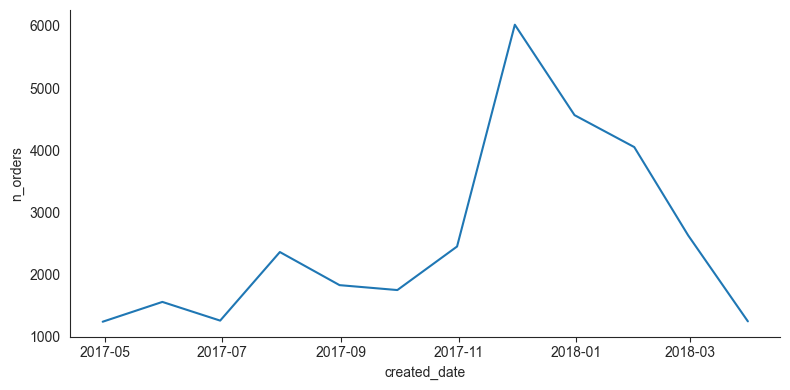

In [81]:
orders_per_month = orders.resample('ME', on='created_date').agg(n_orders = ('order_id', 'count'))
sns.relplot(orders_per_month,
            kind='line',
            x='created_date',
            y='n_orders',
            height=4,
            aspect=2);

Plot number of orders relative to monthly average

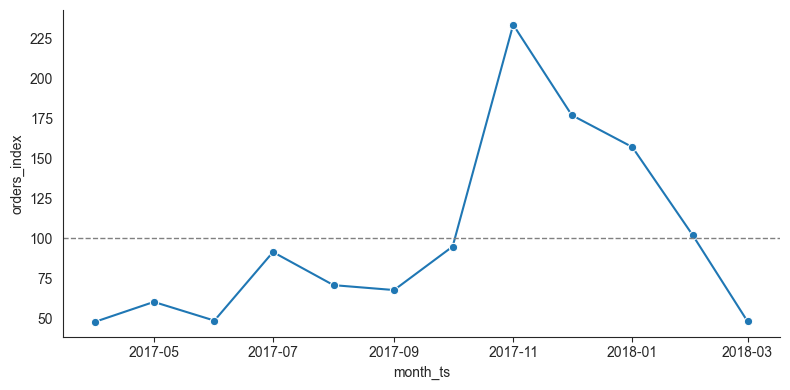

In [82]:
month_orders = sns.relplot(monthly,
            kind='line',
            marker='o',
            x='month_ts',
            y='orders_index',
            height=4,
            aspect=2);
month_orders.ax.axhline(
    y=100,
    linestyle='--',
    color='grey',
    linewidth=1
);

How does seasonality affect number of products sold?

In [83]:
orderlines['month'] = orderlines['date'].dt.to_period("M")
orderlines_monthly = orderlines.groupby('month').agg(sales=('product_quantity', 'sum')).reset_index()
orderlines_monthly['avg_sales'] = orderlines_monthly['sales'].mean()
orderlines_monthly['sales_index'] = orderlines_monthly['sales']/orderlines_monthly['avg_sales']
#convert month (Dtype: period[M]) to timestamp for plotting
orderlines_monthly['month_ts'] = orderlines_monthly['month'].dt.to_timestamp()
orderlines_monthly.sample(10)

,month,sales,avg_sales,sales_index,month_ts
4,2017-05,2320,3375.866667,0.687231,2017-05-01
3,2017-04,1777,3375.866667,0.526383,2017-04-01
13,2018-02,3616,3375.866667,1.071132,2018-02-01
5,2017-06,1873,3375.866667,0.554820,2017-06-01
14,2018-03,1651,3375.866667,0.489060,2018-03-01
9,2017-10,3431,3375.866667,1.016332,2017-10-01
12,2018-01,5563,3375.866667,1.647873,2018-01-01
8,2017-09,2473,3375.866667,0.732553,2017-09-01
0,2017-01,4746,3375.866667,1.405861,2017-01-01
1,2017-02,2339,3375.866667,0.692859,2017-02-01


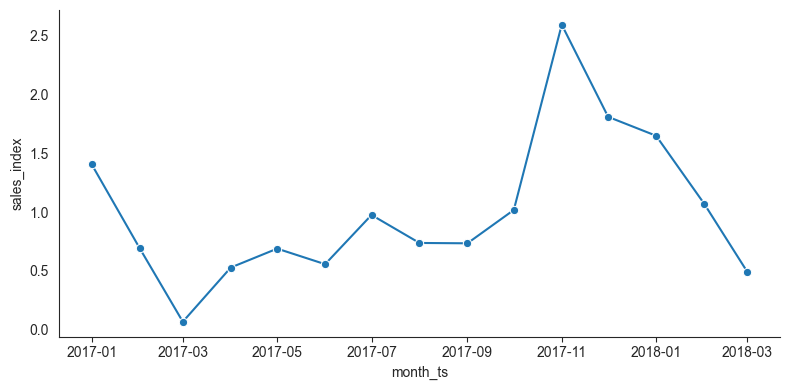

In [84]:
sns.relplot(orderlines_monthly,
            kind='line',
            marker='o',
            x='month_ts',
            y='sales_index',
            height = 4,
            aspect=2);

How does seasonality affect revenue?

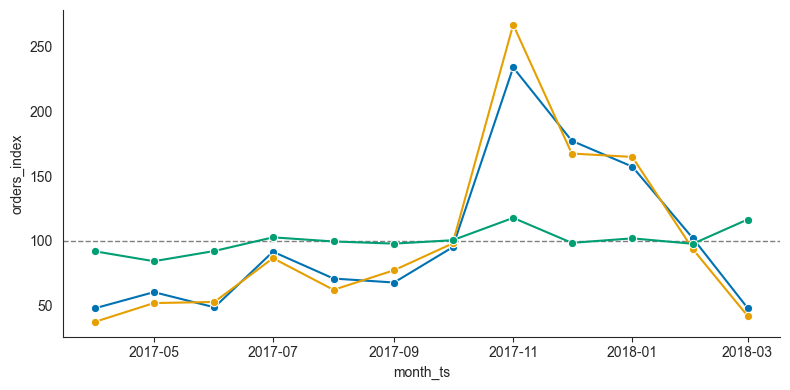

In [85]:
month_orders = sns.relplot(monthly,
            kind='line',
            marker='o',
            x='month_ts',
            y='orders_index',
            color=plot_colours[0],
            height=4,
            aspect=2);
month_orders.ax.axhline(
    y=100,
    linestyle='--',
    color='grey',
    linewidth=1
);

sns.lineplot(
    monthly,
    marker='o',
    x="month_ts",
    y="revenue_index",
    color=plot_colours[1],
    ax=month_orders.ax
)

sns.lineplot(monthly,
            marker='o',
            x='month_ts',
            y='discount_index',
            color=plot_colours[2],
            ax=month_orders.ax);

Make this a presentation-ready plot

In [86]:
monthly.info()

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   month                  12 non-null     period[M]     
 1   revenue                12 non-null     float64       
 2   orders                 12 non-null     int64         
 3   weighted_discount      12 non-null     float64       
 4   avg_revenue            12 non-null     float64       
 5   avg_orders             12 non-null     float64       
 6   avg_weighted_discount  12 non-null     float64       
 7   revenue_index          12 non-null     float64       
 8   orders_index           12 non-null     float64       
 9   discount_index         12 non-null     float64       
 10  month_ts               12 non-null     datetime64[us]
dtypes: datetime64[us](1), float64(8), int64(1), period[M](1)
memory usage: 1.2 KB


1. Just number of orders

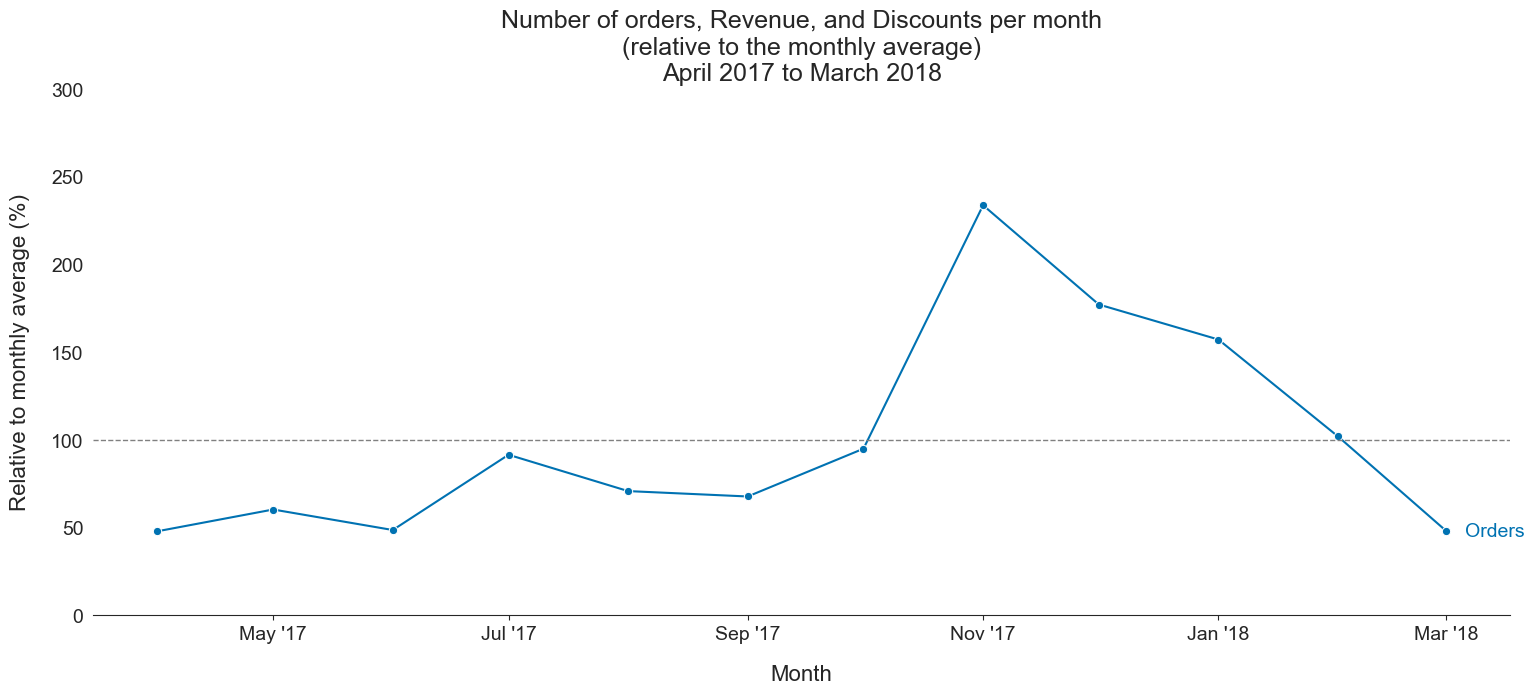

In [87]:
sns.set_style("white",                               # use a different predefined style.
              {'xtick.bottom': True,                 # override some of its defaults
              })                                     # Note: setting the style affects ALL plots from now on!

x_tick_dates = pd.to_datetime([
    "2017-05-01",
    "2017-07-01",
    "2017-09-01",
    "2017-11-01",
    "2018-01-01",
    "2018-03-01",
])
x_tick_labs = ["May '17","Jul '17", "Sep '17", "Nov '17","Jan '18", "Mar '18"]
order_plot = sns.relplot(
            kind="line",
            marker='o',
            data=monthly,
            x='month_ts',
            y="orders_index",
            color=plot_colours[0],
            height=6,
            aspect=2.5)

order_plot.ax.axhline(
    y=100,
    linestyle='--',
    color='grey',
    linewidth=1
);

order_plot.ax.set_autoscale_on(False)

lines = order_plot.ax.lines
labels = ["Orders"]
line_indices = [0, 2, 3]

# vertical offsets (in y-axis units)
y_offsets = {
    "Orders": 0,
}

for idx, label in zip(line_indices, labels):
    line = lines[idx]

    x = line.get_xdata()
    y = line.get_ydata()

    order_plot.ax.text(
        x[-1] + 5,
        y[-1] + y_offsets[label],
        label,
        color=line.get_color(),
        fontsize=14,
        ha="left",
        va="center"
    )

order_plot.ax.set_title('Number of orders, Revenue, and Discounts per month\n(relative to the monthly average)\nApril 2017 to March 2018',
                      fontsize=18)
order_plot.set_axis_labels("Month", "Relative to monthly average (%)", fontsize=16,
                        labelpad=15);                    # move the labels slightly away from the ticks
order_plot.ax.set_xticks(x_tick_dates)                        # set the yticks explicitly before the next step
order_plot.ax.set_xticklabels(x_tick_labs, fontsize=14) # change the xlabel sizes
order_plot.ax.set_ylim(0, 300)
order_plot.ax.set_yticks(order_plot.ax.get_yticks())                        # set the yticks explicitly before the next step
order_plot.ax.set_yticklabels(order_plot.ax.get_yticklabels(), fontsize=14) # change the ylabel sizes

order_plot.ax.spines['left'].set_visible(False)        # remove the edge to the left

Orders and revenue

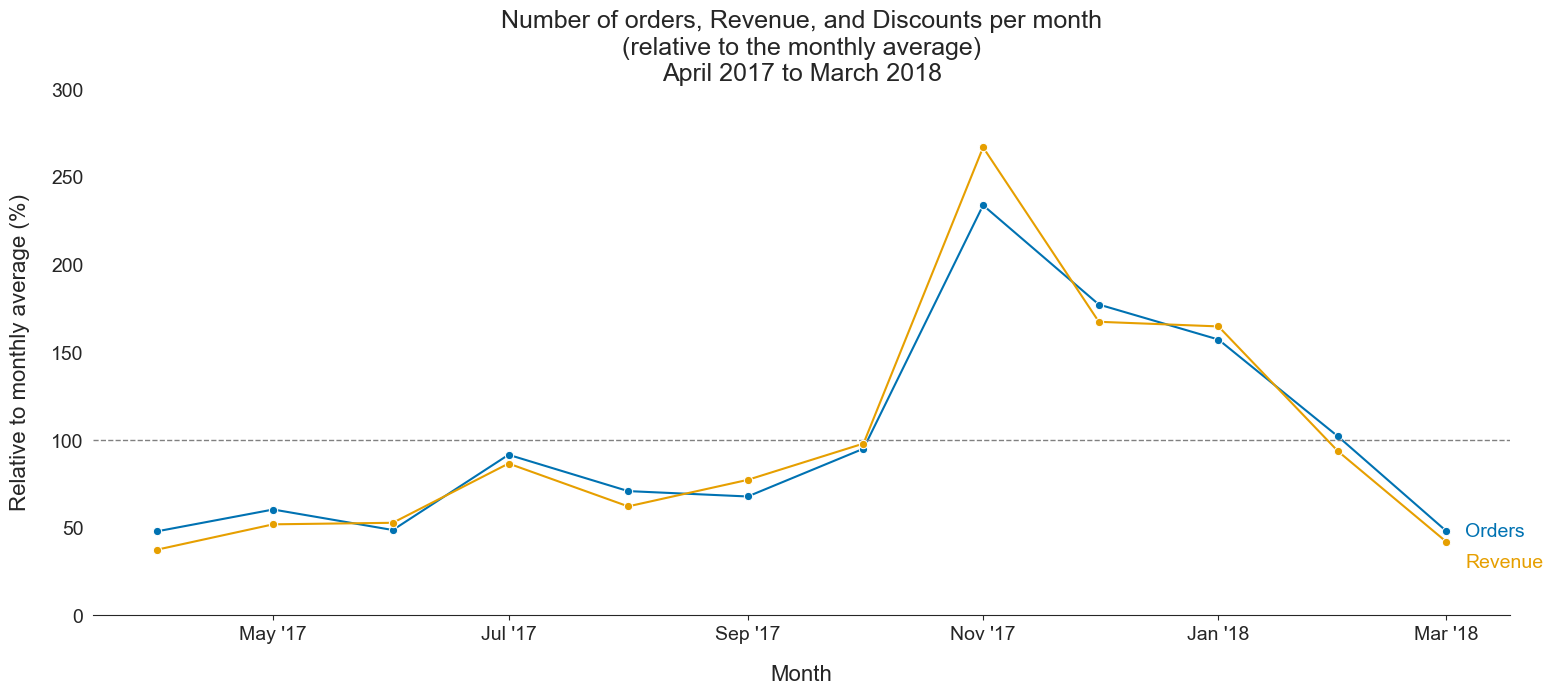

In [88]:
sns.set_style("white",                               # use a different predefined style.
              {'xtick.bottom': True,                 # override some of its defaults
              })                                     # Note: setting the style affects ALL plots from now on!

#x_tick_labs = ["Jan '17", "Mar '17", "May '17","Jul '17", "Sep '17", "Nov '17","Jan '18", "Mar '18"]
order_plot = sns.relplot(
            kind="line",
            marker='o',
            data=monthly,
            x='month_ts',
            y="orders_index",
            color=plot_colours[0],
            height=6,
            aspect=2.5)

order_plot.ax.axhline(
    y=100,
    linestyle='--',
    color='grey',
    linewidth=1
)

sns.lineplot(
    monthly,
    marker='o',
    x="month_ts",
    y="revenue_index",
    color=plot_colours[1],
    ax=order_plot.ax
)

order_plot.ax.set_autoscale_on(False)

lines = order_plot.ax.lines
labels = ["Orders", "Revenue",]
line_indices = [0, 2, 3]

# vertical offsets (in y-axis units)
y_offsets = {
    "Orders": 0,
    "Revenue": -12,   # move revenue down
}

for idx, label in zip(line_indices, labels):
    line = lines[idx]

    x = line.get_xdata()
    y = line.get_ydata()

    order_plot.ax.text(
        x[-1] + 5,
        y[-1] + y_offsets[label],
        label,
        color=line.get_color(),
        fontsize=14,
        ha="left",
        va="center"
    )

order_plot.ax.set_title('Number of orders, Revenue, and Discounts per month\n(relative to the monthly average)\nApril 2017 to March 2018',
                      fontsize=18)
order_plot.set_axis_labels("Month", "Relative to monthly average (%)", fontsize=16,
                        labelpad=15);                    # move the labels slightly away from the ticks
order_plot.ax.set_xticks(x_tick_dates)                        # set the yticks explicitly before the next step
order_plot.ax.set_xticklabels(x_tick_labs, fontsize=14) # change the xlabel sizes
order_plot.ax.set_ylim(0, 300)
order_plot.ax.set_yticks(order_plot.ax.get_yticks())                        # set the yticks explicitly before the next step
order_plot.ax.set_yticklabels(order_plot.ax.get_yticklabels(), fontsize=14) # change the ylabel sizes

order_plot.ax.spines['left'].set_visible(False)        # remove the edge to the left

Orders, revenue, discounts

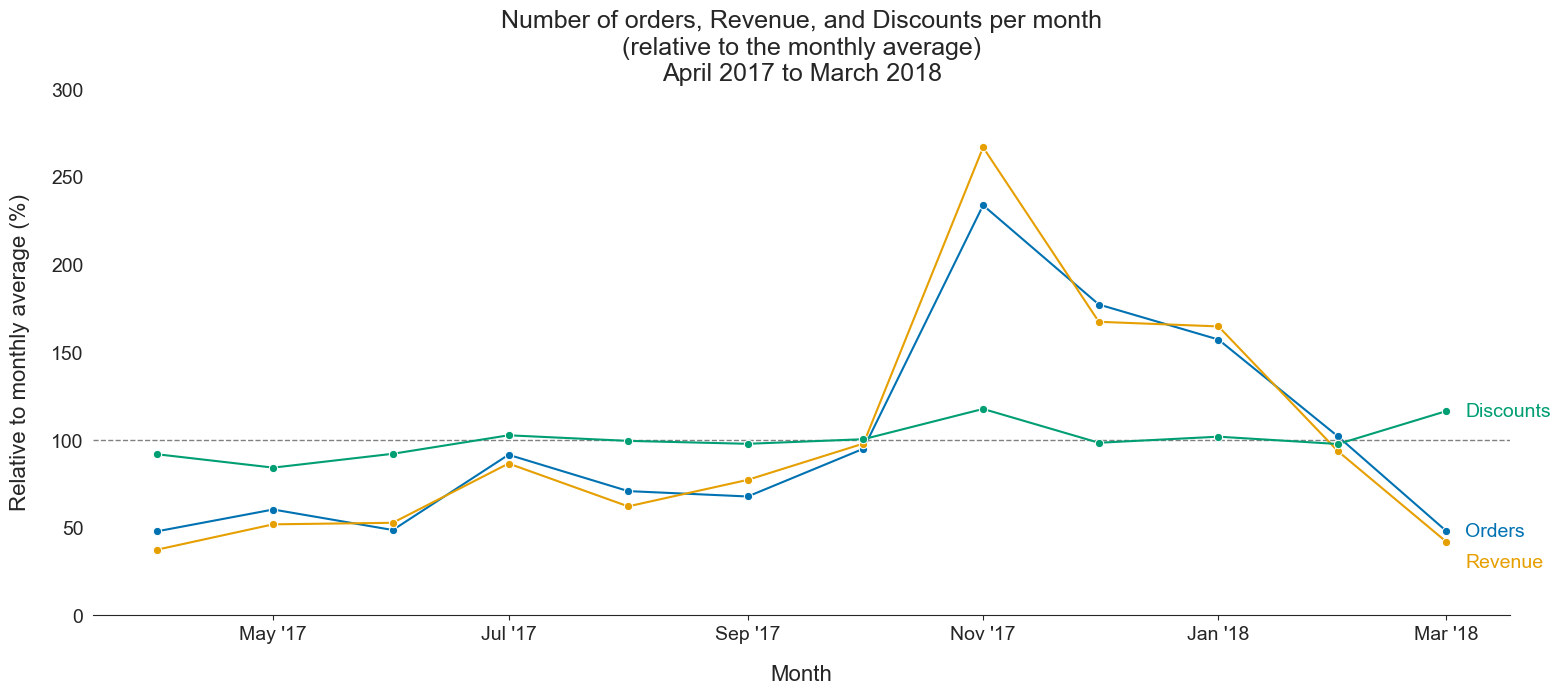

In [89]:
sns.set_style("white",                               # use a different predefined style.
              {'xtick.bottom': True,                 # override some of its defaults
              })                                     # Note: setting the style affects ALL plots from now on!

#x_tick_labs = ["Jan '17", "Mar '17", "May '17","Jul '17", "Sep '17", "Nov '17","Jan '18", "Mar '18"]
order_plot = sns.relplot(
            kind="line",
            marker='o',
            data=monthly,
            x='month_ts',
            y="orders_index",
            color=plot_colours[0],
            height=6,
            aspect=2.5)

order_plot.ax.axhline(
    y=100,
    linestyle='--',
    color='grey',
    linewidth=1
)

sns.lineplot(
    monthly,
    marker='o',
    x="month_ts",
    y="revenue_index",
    color=plot_colours[1],
    ax=order_plot.ax
)

sns.lineplot(
    monthly,
    marker='o',
    x="month_ts",
    y="discount_index",
    color=plot_colours[2],
    ax=order_plot.ax
)

order_plot.ax.set_autoscale_on(False)

lines = order_plot.ax.lines
labels = ["Orders", "Revenue", "Discounts"]
line_indices = [0, 2, 3]

# vertical offsets (in y-axis units)
y_offsets = {
    "Orders": 0,
    "Revenue": -12,   # move revenue down
    "Discounts": 0
}

for idx, label in zip(line_indices, labels):
    line = lines[idx]

    x = line.get_xdata()
    y = line.get_ydata()

    order_plot.ax.text(
        x[-1] + 5,
        y[-1] + y_offsets[label],
        label,
        color=line.get_color(),
        fontsize=14,
        ha="left",
        va="center"
    )

order_plot.ax.set_title('Number of orders, Revenue, and Discounts per month\n(relative to the monthly average)\nApril 2017 to March 2018',
                      fontsize=18)
order_plot.set_axis_labels("Month", "Relative to monthly average (%)", fontsize=16,
                        labelpad=15);                    # move the labels slightly away from the ticks
order_plot.ax.set_xticks(x_tick_dates)                        # set the yticks explicitly before the next step
order_plot.ax.set_xticklabels(x_tick_labs, fontsize=14) # change the xlabel sizes
order_plot.ax.set_ylim(0, 300)
order_plot.ax.set_yticks(order_plot.ax.get_yticks())                        # set the yticks explicitly before the next step
order_plot.ax.set_yticklabels(order_plot.ax.get_yticklabels(), fontsize=14) # change the ylabel sizes

order_plot.ax.spines['left'].set_visible(False)        # remove the edge to the left

Blank plot for presentation

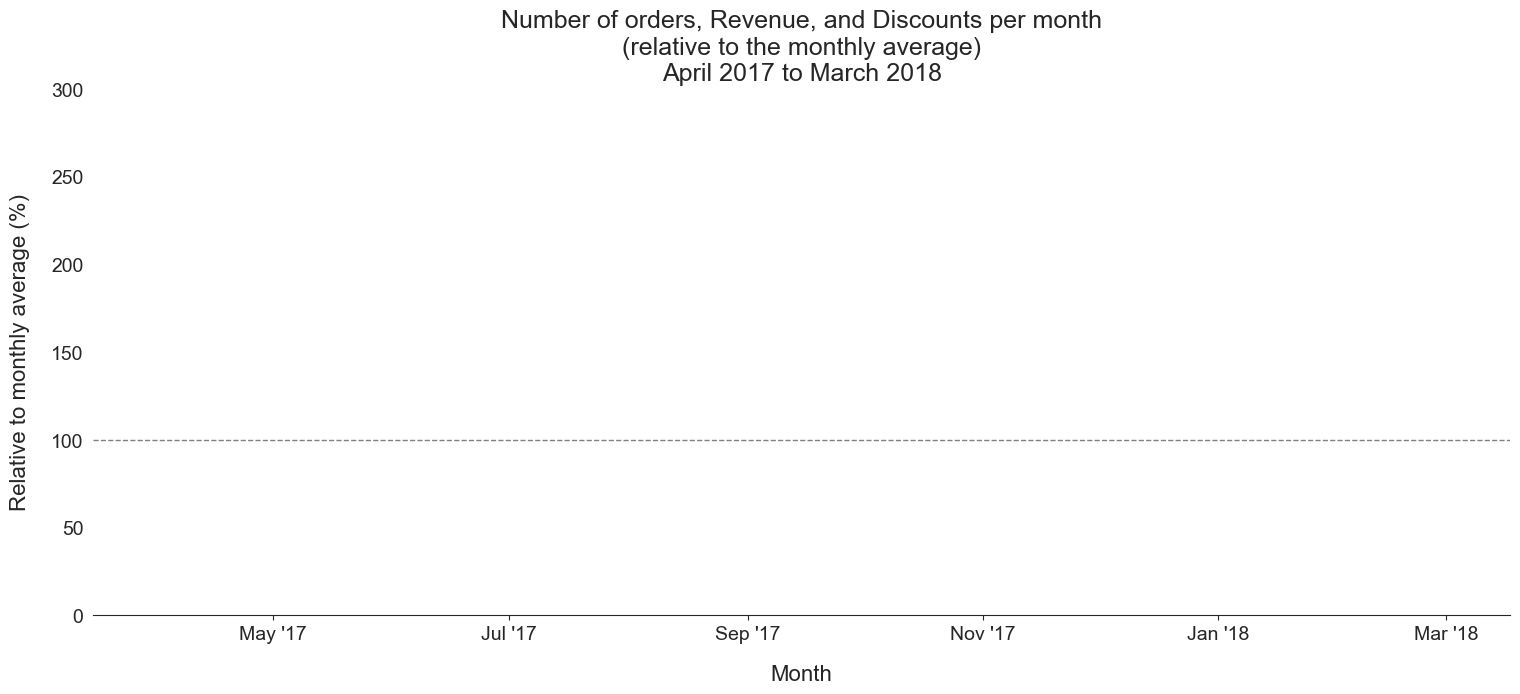

In [90]:
sns.set_style("white",                               # use a different predefined style.
              {'xtick.bottom': True,                 # override some of its defaults
              })                                     # Note: setting the style affects ALL plots from now on!

#x_tick_labs = ["Jan '17", "Mar '17", "May '17","Jul '17", "Sep '17", "Nov '17","Jan '18", "Mar '18"]
order_plot = sns.relplot(
            kind="line",
            marker='o',
            data=monthly,
            x='month_ts',
            y="orders_index",
            color='#FFFFFF',
            height=6,
            aspect=2.5)

order_plot.ax.axhline(
    y=100,
    linestyle='--',
    color='grey',
    linewidth=1
)


order_plot.ax.set_title('Number of orders, Revenue, and Discounts per month\n(relative to the monthly average)\nApril 2017 to March 2018',
                      fontsize=18)
order_plot.set_axis_labels("Month", "Relative to monthly average (%)", fontsize=16,
                        labelpad=15);                    # move the labels slightly away from the ticks
order_plot.ax.set_xticks(x_tick_dates)                        # set the yticks explicitly before the next step
order_plot.ax.set_xticklabels(x_tick_labs, fontsize=14) # change the xlabel sizes
order_plot.ax.set_ylim(0, 300)
order_plot.ax.set_yticks(order_plot.ax.get_yticks())                        # set the yticks explicitly before the next step
order_plot.ax.set_yticklabels(order_plot.ax.get_yticklabels(), fontsize=14) # change the ylabel sizes

order_plot.ax.spines['left'].set_visible(False)        # remove the edge to the left

## Extra plots for presentation (not in main presentation)

Daily plot to highlight Black Friday and Cyber Monday

In [91]:
orders['day'] = orders['created_date'].dt.to_period("D")
daily = orders.groupby('day').agg(revenue=('total_paid', 'sum'), orders=('order_id', 'nunique'), weighted_discount = ('order_weighted_discount', 'mean')).reset_index()
daily['avg_revenue'] = daily['revenue'].mean()
daily['avg_orders'] = daily['orders'].mean()
daily['avg_weighted_discount'] = daily['weighted_discount'].mean()
daily['revenue_index'] = 100*daily['revenue']/daily['avg_revenue']
daily['orders_index'] = 100*daily['orders']/daily['avg_orders']
daily['discount_index'] = 100*daily['weighted_discount']/daily['avg_weighted_discount']
#convert month (Dtype: period[M]) to timestamp for plotting
daily['day_ts'] = daily['day'].dt.to_timestamp()
daily.sample(10)

,day,revenue,orders,weighted_discount,avg_revenue,avg_orders,avg_weighted_discount,revenue_index,orders_index,discount_index,day_ts
217,2017-11-04,14022.58,43,0.133675,34390.294741,88.807471,0.141699,40.774818,48.419350,94.337186,2017-11-04
295,2018-01-21,26905.87,62,0.159058,34390.294741,88.807471,0.141699,78.236811,69.813946,112.250831,2018-01-21
310,2018-02-05,32137.61,115,0.144226,34390.294741,88.807471,0.141699,93.449650,129.493609,101.783521,2018-02-05
213,2017-10-31,40867.77,144,0.143271,34390.294741,88.807471,0.141699,118.835184,162.148520,101.109547,2017-10-31
193,2017-10-11,28828.81,66,0.139801,34390.294741,88.807471,0.141699,83.828331,74.318072,98.660502,2017-10-11
334,2018-03-01,44948.94,96,0.127448,34390.294741,88.807471,0.141699,130.702398,108.099013,89.942603,2018-03-01
230,2017-11-17,15437.63,49,0.128863,34390.294741,88.807471,0.141699,44.889496,55.175538,90.941486,2017-11-17
134,2017-08-13,2996.52,18,0.150898,34390.294741,88.807471,0.141699,8.713272,20.268565,106.492322,2017-08-13
315,2018-02-10,24580.51,60,0.125748,34390.294741,88.807471,0.141699,71.475136,67.561883,88.742790,2018-02-10
243,2017-11-30,58203.45,135,0.163591,34390.294741,88.807471,0.141699,169.243824,152.014237,115.449453,2017-11-30


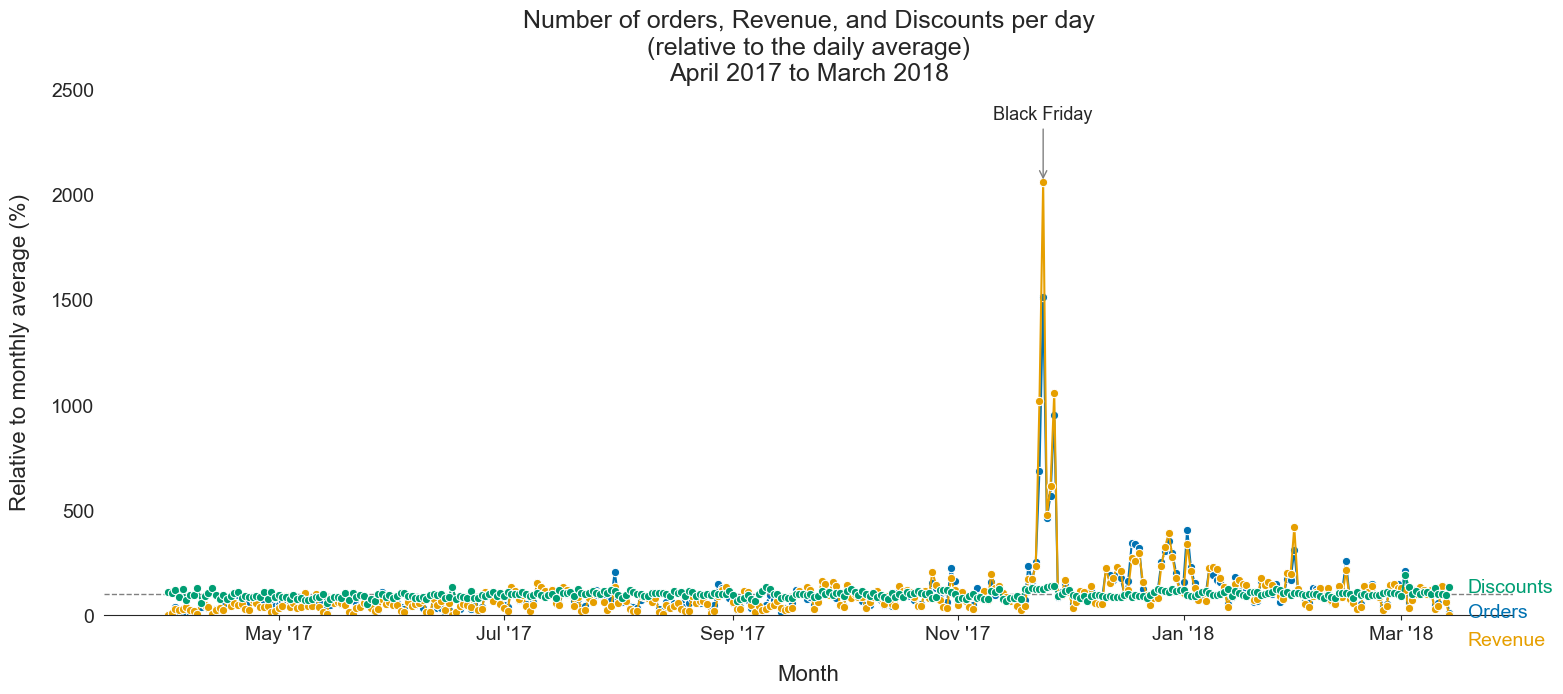

In [92]:
sns.set_style("white",                               # use a different predefined style.
              {'xtick.bottom': True,                 # override some of its defaults
              })                                     # Note: setting the style affects ALL plots from now on!

#x_tick_labs = ["Jan '17", "Mar '17", "May '17","Jul '17", "Sep '17", "Nov '17","Jan '18", "Mar '18"]
order_plot = sns.relplot(
            kind="line",
            marker='o',
            data=daily,
            x='day_ts',
            y="orders_index",
            color=plot_colours[0],
            height=6,
            aspect=2.5)

order_plot.ax.axhline(
    y=100,
    linestyle='--',
    color='grey',
    linewidth=1
)

sns.lineplot(
    daily,
    marker='o',
    x="day_ts",
    y="revenue_index",
    color=plot_colours[1],
    ax=order_plot.ax
)

sns.lineplot(
    daily,
    marker='o',
    x="day_ts",
    y="discount_index",
    color=plot_colours[2],
    ax=order_plot.ax
)

order_plot.ax.set_autoscale_on(False)

# ---- Line end labels ----
lines = order_plot.ax.lines
labels = ["Orders", "Revenue", "Discounts"]
line_indices = [0, 2, 3]

y_offsets = {
    "Orders": 0,
    "Revenue": -120,   # larger offset for daily data
    "Discounts": 0
}

for idx, label in zip(line_indices, labels):
    line = lines[idx]

    x = line.get_xdata()
    y = line.get_ydata()

    order_plot.ax.text(
        x[-1] + 5,
        y[-1] + y_offsets[label],
        label,
        color=line.get_color(),
        fontsize=14,
        ha="left",
        va="center"
    )

# ---- Date annotations ----
annotations = {
    "2017-11-24": "Black Friday"
}

for date_str, label in annotations.items():
    date = pd.to_datetime(date_str)

    y = daily.loc[daily["day_ts"] == date, "revenue_index"].iloc[0]

    order_plot.ax.annotate(
        label,
        xy=(date, y),
        xytext=(date, y + 300),
        arrowprops=dict(arrowstyle="->", color="grey"),
        ha="center",
        fontsize=13
    )

order_plot.ax.set_title('Number of orders, Revenue, and Discounts per day\n(relative to the daily average)\nApril 2017 to March 2018',
                      fontsize=18)
order_plot.set_axis_labels("Month", "Relative to monthly average (%)", fontsize=16,
                        labelpad=15);                    # move the labels slightly away from the ticks
order_plot.ax.set_xticks(x_tick_dates)                        # set the yticks explicitly before the next step
order_plot.ax.set_xticklabels(x_tick_labs, fontsize=14) # change the xlabel sizes
order_plot.ax.set_ylim(0, 2500)
order_plot.ax.set_yticks(order_plot.ax.get_yticks())                        # set the yticks explicitly before the next step
order_plot.ax.set_yticklabels(order_plot.ax.get_yticklabels(), fontsize=14) # change the ylabel sizes

order_plot.ax.spines['left'].set_visible(False)        # remove the edge to the left

For backup plots - look at orders, discounts and revenue only for top 3 product categories in terms of revenue (Cables and Connectivity, Apple Smartphones, Accessories: cases)

In [94]:
orderlines['category'].unique()

<StringArray>
[     'Accessories: cases',           'Apple Display',
                 'Storage', 'Cables and Connectivity',
              'Components',                'Displays',
                  'Server',              'Other Tech',
       'Apple Mediaplayer',            'Apple Laptop',
            'Other tablet',        'Apple Smartphone',
            'Apple Tablet',             'Apple Watch']
Length: 14, dtype: str

In [96]:
orderlines['month'] = orderlines['date'].dt.to_period("M")
orderlines_top3 = orderlines[orderlines['category'].isin(['Cables and Connectivity', 'Apple Smartphone', 'Accessories: cases'])].copy()
orderlines_monthly = orderlines_top3.groupby('month').agg(sales=('product_quantity', 'sum')).reset_index()
orderlines_monthly['avg_sales'] = orderlines_monthly['sales'].mean()
orderlines_monthly['sales_index'] = orderlines_monthly['sales']/orderlines_monthly['avg_sales']
#convert month (Dtype: period[M]) to timestamp for plotting
orderlines_monthly['month_ts'] = orderlines_monthly['month'].dt.to_timestamp()
orderlines_monthly.sample(10)

,month,sales,avg_sales,sales_index,month_ts
9,2017-10,2010,2076.333333,0.968053,2017-10-01
5,2017-06,1152,2076.333333,0.554824,2017-06-01
11,2017-12,4056,2076.333333,1.953444,2017-12-01
2,2017-03,112,2076.333333,0.053941,2017-03-01
3,2017-04,1130,2076.333333,0.544229,2017-04-01
12,2018-01,3529,2076.333333,1.699631,2018-01-01
1,2017-02,1346,2076.333333,0.648258,2017-02-01
0,2017-01,2921,2076.333333,1.406807,2017-01-01
13,2018-02,2289,2076.333333,1.102424,2018-02-01
4,2017-05,1380,2076.333333,0.664633,2017-05-01


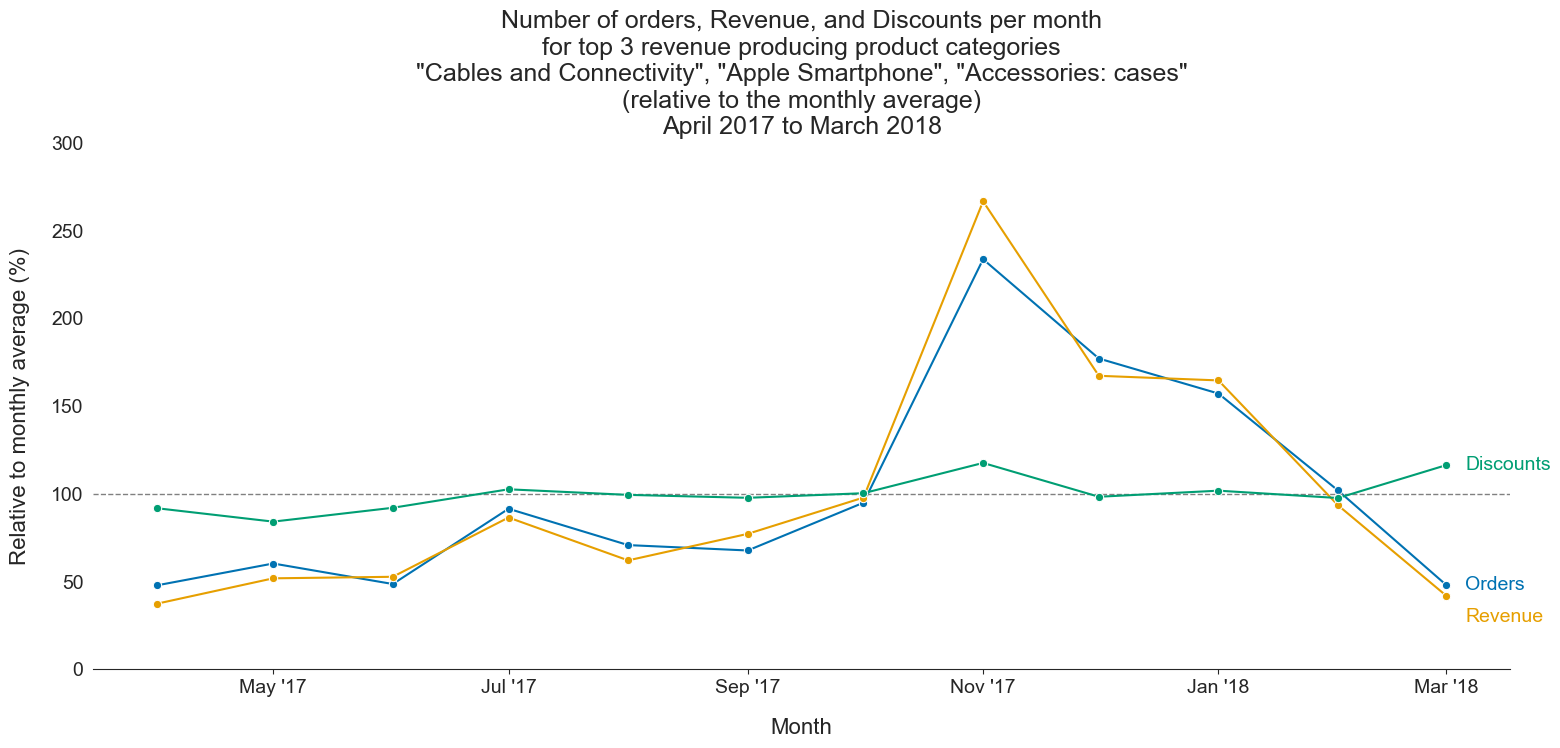

In [98]:
sns.set_style("white",                               # use a different predefined style.
              {'xtick.bottom': True,                 # override some of its defaults
              })                                     # Note: setting the style affects ALL plots from now on!

#x_tick_labs = ["Jan '17", "Mar '17", "May '17","Jul '17", "Sep '17", "Nov '17","Jan '18", "Mar '18"]
order_plot = sns.relplot(
            kind="line",
            marker='o',
            data=monthly,
            x='month_ts',
            y="orders_index",
            color=plot_colours[0],
            height=6,
            aspect=2.5)

order_plot.ax.axhline(
    y=100,
    linestyle='--',
    color='grey',
    linewidth=1
)

sns.lineplot(
    monthly,
    marker='o',
    x="month_ts",
    y="revenue_index",
    color=plot_colours[1],
    ax=order_plot.ax
)

sns.lineplot(
    monthly,
    marker='o',
    x="month_ts",
    y="discount_index",
    color=plot_colours[2],
    ax=order_plot.ax
)

order_plot.ax.set_autoscale_on(False)

lines = order_plot.ax.lines
labels = ["Orders", "Revenue", "Discounts"]
line_indices = [0, 2, 3]

# vertical offsets (in y-axis units)
y_offsets = {
    "Orders": 0,
    "Revenue": -12,   # move revenue down
    "Discounts": 0
}

for idx, label in zip(line_indices, labels):
    line = lines[idx]

    x = line.get_xdata()
    y = line.get_ydata()

    order_plot.ax.text(
        x[-1] + 5,
        y[-1] + y_offsets[label],
        label,
        color=line.get_color(),
        fontsize=14,
        ha="left",
        va="center"
    )

order_plot.ax.set_title('Number of orders, Revenue, and Discounts per month\nfor top 3 revenue producing product categories\n"Cables and Connectivity", "Apple Smartphone", "Accessories: cases"\n(relative to the monthly average)\nApril 2017 to March 2018',
                      fontsize=18)
order_plot.set_axis_labels("Month", "Relative to monthly average (%)", fontsize=16,
                        labelpad=15);                    # move the labels slightly away from the ticks
order_plot.ax.set_xticks(x_tick_dates)                        # set the yticks explicitly before the next step
order_plot.ax.set_xticklabels(x_tick_labs, fontsize=14) # change the xlabel sizes
order_plot.ax.set_ylim(0, 300)
order_plot.ax.set_yticks(order_plot.ax.get_yticks())                        # set the yticks explicitly before the next step
order_plot.ax.set_yticklabels(order_plot.ax.get_yticklabels(), fontsize=14) # change the ylabel sizes

order_plot.ax.spines['left'].set_visible(False)        # remove the edge to the left